# Daily Return Calculation

This notebook computes daily percentage changes in closing prices using the formula:
```
Daily Return (%) = (Close_t - Close_{t-1}) / Close_{t-1} * 100
```

## Contents:
- Load stock price data
- Calculate daily returns for each stock
- Analyze return statistics
- Visualize return distributions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from datetime import datetime

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Stock Price Data

In [ ]:
# Define path to stock data
stock_data_path = '../../../../data/raw/yfinance_da../../../data/'

# Get list of all stock CSV files
stock_files = glob.glob(os.path.join(stock_data_path, '*.csv'))

print(f"Found {len(stock_files)} stock files:")
for file in stock_files:
    print(f"  - {os.path.basename(file)}")

# Load all stock data
stock_data = {}

for file_path in stock_files:
    symbol = os.path.basename(file_path).replace('.csv', '')
    
    try:
        # Load CSV with proper data types
        df = pd.read_csv(file_path)
        
        # Convert Date column to datetime
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        
        # Ensure numeric columns are properly typed
        numeric_columns = ['Open', 'High', 'Low', 'Close', 'Volume']
        for col in numeric_columns:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
        
        # Sort by date
        df = df.sort_values('Date').reset_index(drop=True)
        
        stock_data[symbol] = df
        
        print(f"✅ {symbol}: Loaded {len(df)} rows from {df['Date'].min().date()} to {df['Date'].max().date()}")
        
    except Exception as e:
        print(f"❌ Error loading {symbol}: {e}")

print(f"\n✅ Successfully loaded {len(stock_data)} stock datasets")

Found 5 stock files:
  - AAPL.csv
  - AMZN.csv
  - GOOG.csv
  - META.csv
  - NVDA.csv
✅ AAPL: Loaded 3774 rows from 2009-01-02 to 2023-12-29
✅ AMZN: Loaded 3774 rows from 2009-01-02 to 2023-12-29
✅ GOOG: Loaded 3774 rows from 2009-01-02 to 2023-12-29
✅ META: Loaded 2923 rows from 2012-05-18 to 2023-12-29
✅ NVDA: Loaded 3774 rows from 2009-01-02 to 2023-12-29

✅ Successfully loaded 5 stock datasets


## 2. Calculate Daily Returns

In [3]:
def calculate_daily_returns(df):
    """
    Calculate daily percentage returns using the formula:
    Daily Return (%) = (Close_t - Close_{t-1}) / Close_{t-1} * 100
    """
    returns_df = df.copy()
    
    # Calculate daily returns
    returns_df['Daily_Return'] = ((returns_df['Close'] - returns_df['Close'].shift(1)) / 
                                returns_df['Close'].shift(1)) * 100
    
    # Handle the first row (no previous day's data)
    returns_df.loc[0, 'Daily_Return'] = np.nan
    
    return returns_df

# Calculate returns for all stocks
stock_returns = {}

for symbol, df in stock_data.items():
    stock_returns[symbol] = calculate_daily_returns(df)
    
    # Display basic return statistics
    returns = stock_returns[symbol]['Daily_Return'].dropna()
    
    print(f"\n{symbol} - Daily Return Statistics:")
    print(f"  - Mean Daily Return: {returns.mean():.4f}%")
    print(f"  - Std Dev: {returns.std():.4f}%")
    print(f"  - Min Return: {returns.min():.4f}%")
    print(f"  - Max Return: {returns.max():.4f}%")
    print(f"  - Total Trading Days: {len(returns)}")

print("\n✅ Daily returns calculated for all stocks!")


AAPL - Daily Return Statistics:
  - Mean Daily Return: 0.1289%
  - Std Dev: 1.8010%
  - Min Return: -12.8647%
  - Max Return: 11.9808%
  - Total Trading Days: 3773

AMZN - Daily Return Statistics:
  - Mean Daily Return: 0.1303%
  - Std Dev: 2.1829%
  - Min Return: -14.0494%
  - Max Return: 26.7951%
  - Total Trading Days: 3773

GOOG - Daily Return Statistics:
  - Mean Daily Return: 0.0910%
  - Std Dev: 1.7334%
  - Min Return: -11.1008%
  - Max Return: 16.0524%
  - Total Trading Days: 3773

META - Daily Return Statistics:
  - Mean Daily Return: 0.1082%
  - Std Dev: 2.5280%
  - Min Return: -26.3901%
  - Max Return: 29.6115%
  - Total Trading Days: 2922

NVDA - Daily Return Statistics:
  - Mean Daily Return: 0.1877%
  - Std Dev: 2.8917%
  - Min Return: -18.7558%
  - Max Return: 29.8067%
  - Total Trading Days: 3773

✅ Daily returns calculated for all stocks!


## 3. Display Sample Data with Returns

In [4]:
# Display sample data with daily returns for the first stock
sample_symbol = list(stock_returns.keys())[0]
sample_data = stock_returns[sample_symbol]

print(f"Sample data for {sample_symbol} with daily returns:")
print(sample_data[['Date', 'Close', 'Daily_Return']].head(15))

# Show some extreme return days
print(f"\n{sample_symbol} - Top 10 Positive Return Days:")
top_positive = sample_data.nlargest(10, 'Daily_Return')[['Date', 'Close', 'Daily_Return']]
print(top_positive.to_string(index=False))

print(f"\n{sample_symbol} - Top 10 Negative Return Days:")
top_negative = sample_data.nsmallest(10, 'Daily_Return')[['Date', 'Close', 'Daily_Return']]
print(top_negative.to_string(index=False))

Sample data for AAPL with daily returns:
         Date     Close  Daily_Return
0  2009-01-02  2.721686           NaN
1  2009-01-05  2.836553      4.220416
2  2009-01-06  2.789767     -1.649399
3  2009-01-07  2.729484     -2.160860
4  2009-01-08  2.780169      1.856959
5  2009-01-09  2.716589     -2.286921
6  2009-01-12  2.659007     -2.119649
7  2009-01-13  2.630514     -1.071572
8  2009-01-14  2.559135     -2.713489
9  2009-01-15  2.500652     -2.285260
10 2009-01-16  2.469163     -1.259246
11 2009-01-20  2.345299     -5.016406
12 2009-01-21  2.484158      5.920707
13 2009-01-22  2.650008      6.676333
14 2009-01-23  2.650008      0.000000

AAPL - Top 10 Positive Return Days:
      Date      Close  Daily_Return
2020-03-13  67.227592     11.980808
2020-07-31 103.075043     10.468859
2020-03-24  59.708412     10.032528
2020-03-02  72.267792      9.310060
2022-11-10 144.687180      8.897421
2012-04-25  18.294531      8.874106
2020-04-06  63.478893      8.723733
2014-04-24  17.716208     

## 4. Return Distribution Analysis

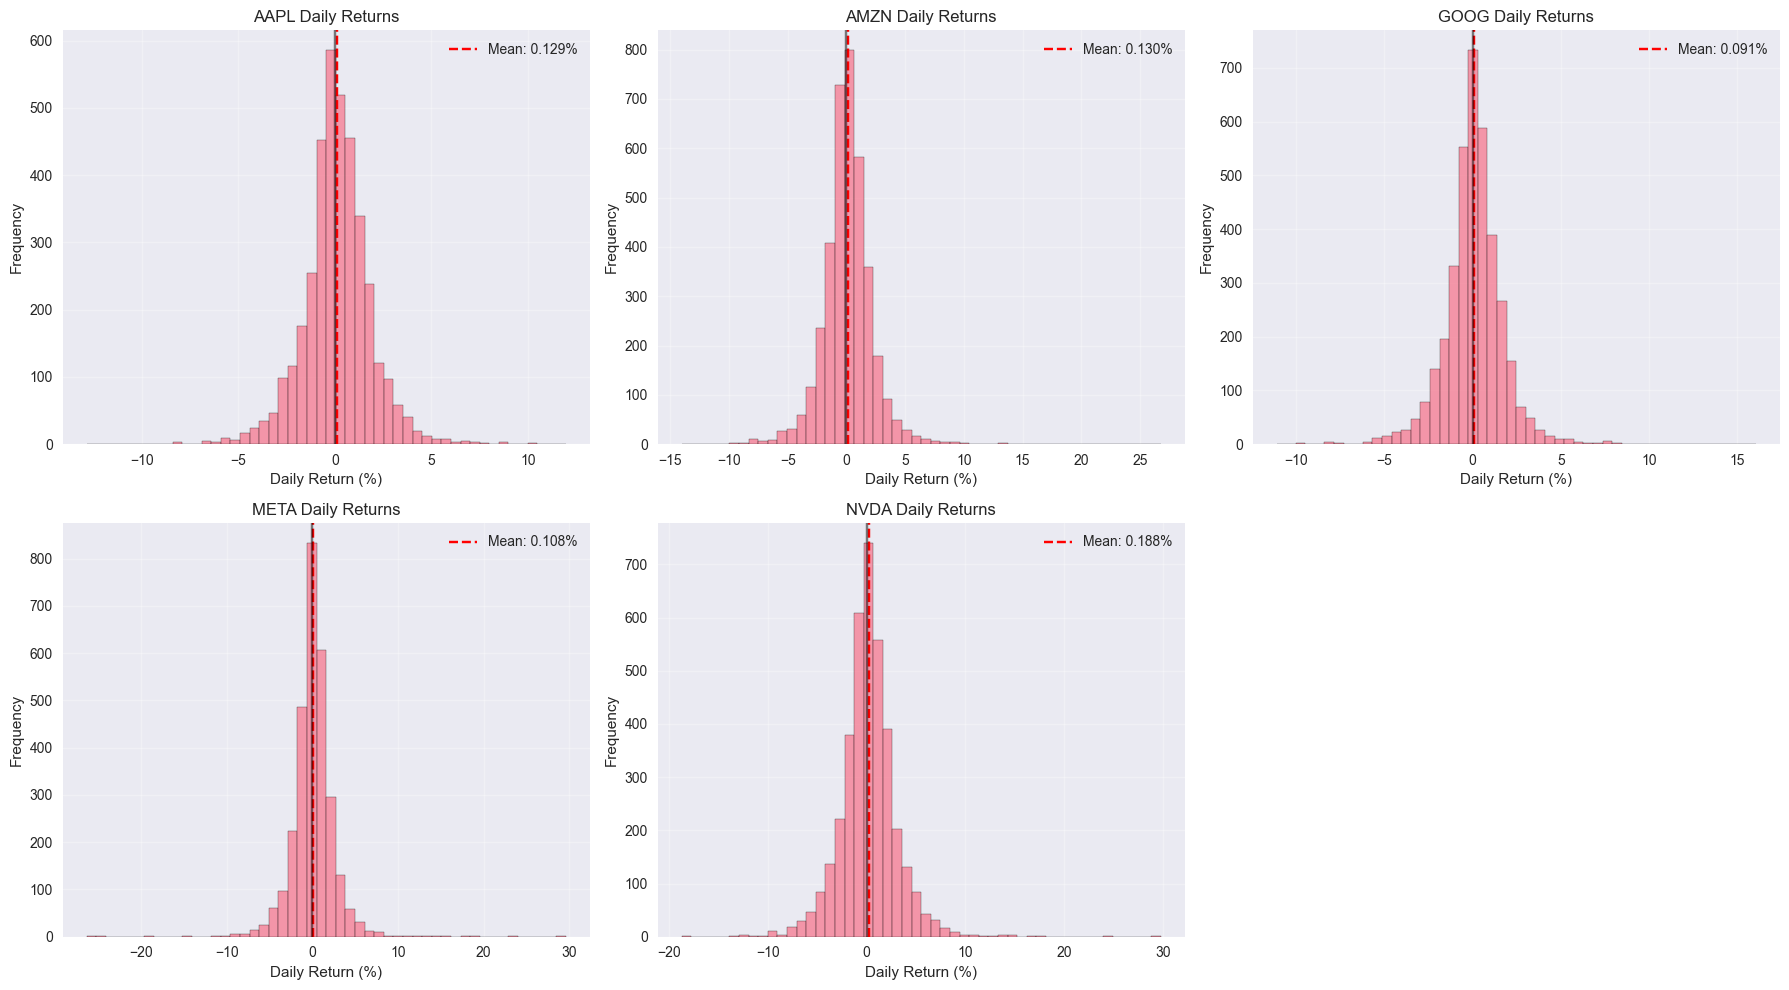

In [5]:
# Create subplots for return distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (symbol, returns_df) in enumerate(stock_returns.items()):
    if i < len(axes):
        returns = returns_df['Daily_Return'].dropna()
        
        # Plot histogram
        axes[i].hist(returns, bins=50, alpha=0.7, edgecolor='black')
        axes[i].axvline(returns.mean(), color='red', linestyle='--', 
                       label=f'Mean: {returns.mean():.3f}%')
        axes[i].axvline(0, color='black', linestyle='-', alpha=0.5)
        axes[i].set_title(f'{symbol} Daily Returns')
        axes[i].set_xlabel('Daily Return (%)')
        axes[i].set_ylabel('Frequency')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

# Remove empty subplots
for i in range(len(stock_returns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

## 5. Comparative Return Statistics

In [6]:
# Create summary statistics table
summary_stats = []

for symbol, returns_df in stock_returns.items():
    returns = returns_df['Daily_Return'].dropna()
    
    stats = {
        'Symbol': symbol,
        'Mean_Return': returns.mean(),
        'Std_Dev': returns.std(),
        'Min_Return': returns.min(),
        'Max_Return': returns.max(),
        'Median_Return': returns.median(),
        'Skewness': returns.skew(),
        'Kurtosis': returns.kurtosis(),
        'Trading_Days': len(returns),
        'Positive_Days': (returns > 0).sum(),
        'Negative_Days': (returns < 0).sum()
    }
    
    summary_stats.append(stats)

# Convert to DataFrame
summary_df = pd.DataFrame(summary_stats)

# Display summary statistics
print("Daily Return Summary Statistics:")
print(summary_df.round(4))

# Calculate win rate (percentage of positive return days)
summary_df['Win_Rate'] = (summary_df['Positive_Days'] / 
                         (summary_df['Positive_Days'] + summary_df['Negative_Days'])) * 100

print("\nWin Rate (Positive Return Days %):")
for _, row in summary_df.iterrows():
    print(f"  {row['Symbol']}: {row['Win_Rate']:.1f}%")

Daily Return Summary Statistics:
  Symbol  Mean_Return  Std_Dev  Min_Return  Max_Return  Median_Return  \
0   AAPL       0.1289   1.8010    -12.8647     11.9808         0.1062   
1   AMZN       0.1303   2.1829    -14.0494     26.7951         0.0916   
2   GOOG       0.0910   1.7334    -11.1008     16.0524         0.0724   
3   META       0.1082   2.5280    -26.3901     29.6115         0.0998   
4   NVDA       0.1877   2.8917    -18.7558     29.8067         0.1664   

   Skewness  Kurtosis  Trading_Days  Positive_Days  Negative_Days  
0   -0.0186    4.6871          3773           2003           1763  
1    0.8765   11.6900          3773           1981           1784  
2    0.3730    7.8325          3773           1991           1781  
3    0.2896   20.8951          2922           1526           1385  
4    0.5234    7.7607          3773           1992           1757  

Win Rate (Positive Return Days %):
  AAPL: 53.2%
  AMZN: 52.6%
  GOOG: 52.8%
  META: 52.4%
  NVDA: 53.1%


## 6. Cumulative Returns Analysis

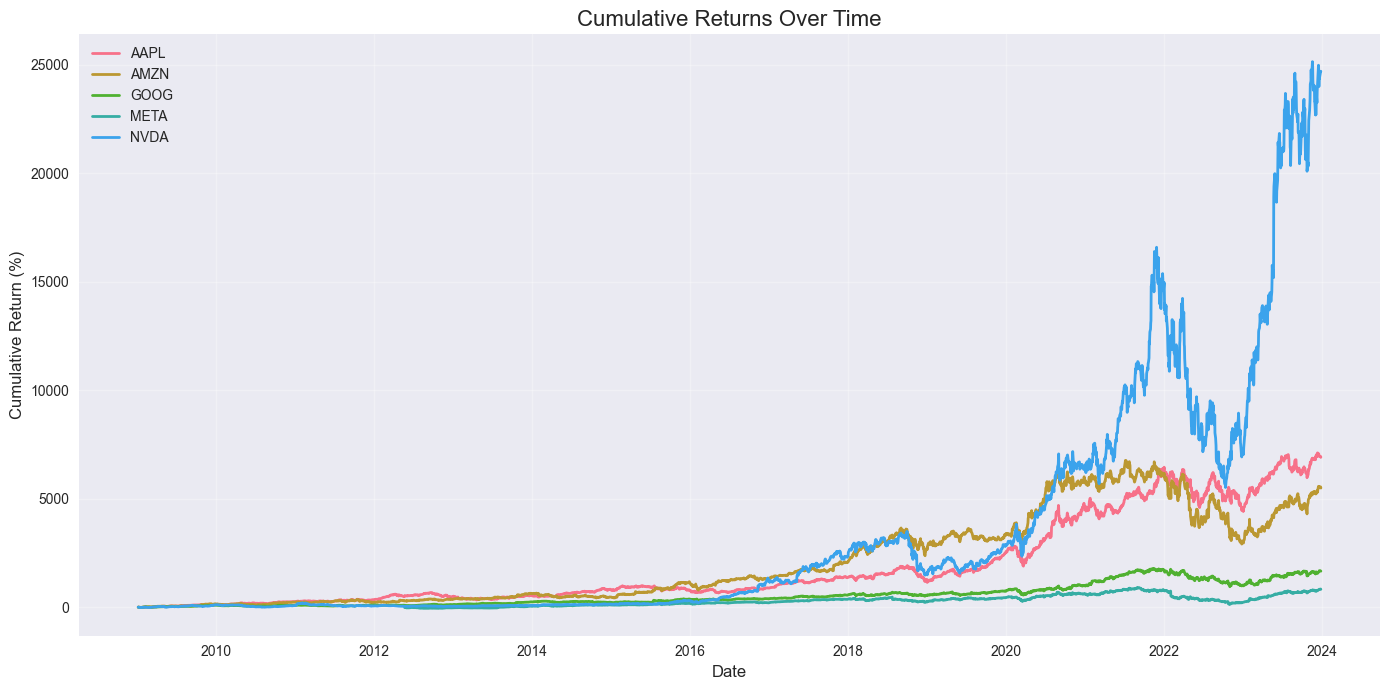

Final Cumulative Returns:
  AAPL: 6907.74%
  AMZN: 5490.14%
  GOOG: 1660.96%
  META: 825.87%
  NVDA: 24691.75%


In [7]:
# Calculate cumulative returns
plt.figure(figsize=(14, 7))

for symbol, returns_df in stock_returns.items():
    # Calculate cumulative returns
    returns_df['Cumulative_Return'] = (1 + returns_df['Daily_Return'] / 100).cumprod() - 1
    
    # Plot cumulative returns
    plt.plot(returns_df['Date'], returns_df['Cumulative_Return'] * 100, 
            label=symbol, linewidth=2)

plt.title('Cumulative Returns Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return (%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Display final cumulative returns
print("Final Cumulative Returns:")
for symbol, returns_df in stock_returns.items():
    final_return = returns_df['Cumulative_Return'].iloc[-1] * 100
    print(f"  {symbol}: {final_return:.2f}%")

## 7. Volatility Analysis

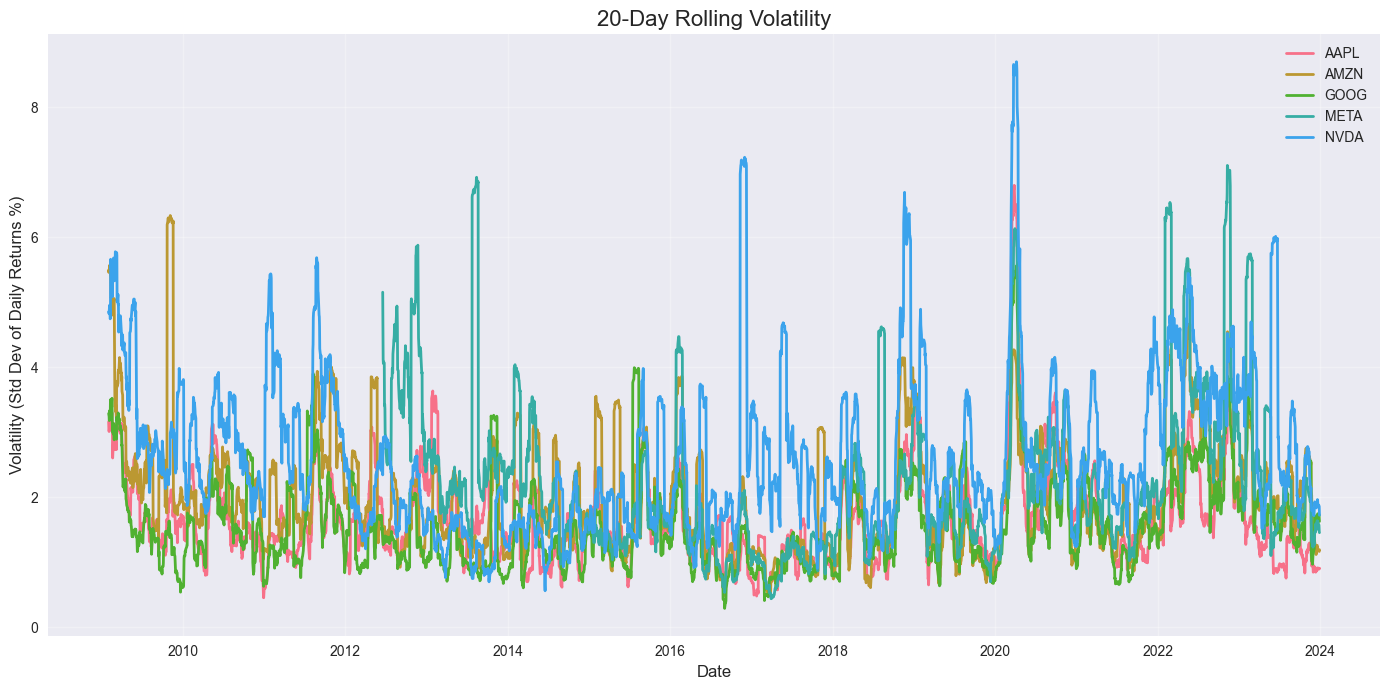

Average Volatility (20-day rolling std dev):
  AAPL: 1.6551%
  AMZN: 1.9922%
  GOOG: 1.5837%
  META: 2.2180%
  NVDA: 2.6299%


In [8]:
# Calculate rolling volatility (20-day standard deviation)
plt.figure(figsize=(14, 7))

for symbol, returns_df in stock_returns.items():
    # Calculate 20-day rolling volatility
    returns_df['Rolling_Volatility'] = returns_df['Daily_Return'].rolling(window=20).std()
    
    # Plot rolling volatility
    plt.plot(returns_df['Date'], returns_df['Rolling_Volatility'], 
            label=symbol, linewidth=2)

plt.title('20-Day Rolling Volatility', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Volatility (Std Dev of Daily Returns %)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Display average volatility
print("Average Volatility (20-day rolling std dev):")
for symbol, returns_df in stock_returns.items():
    avg_vol = returns_df['Rolling_Volatility'].mean()
    print(f"  {symbol}: {avg_vol:.4f}%")

## 8. Save Results

In [ ]:
# Create output directory if it doesn't exist
output_dir = '../../../../data/processed/daily_returns/'
os.makedirs(output_dir, exist_ok=True)

# Save daily returns data for each stock
for symbol, returns_df in stock_returns.items():
    output_file = os.path.join(output_dir, f'{symbol}_daily_returns.csv')
    
    # Save relevant columns
    columns_to_save = ['Date', 'Close', 'Daily_Return', 'Cumulative_Return', 'Rolling_Volatility']
    returns_df[columns_to_save].to_csv(output_file, index=False)
    
    print(f"✅ Saved {symbol} daily returns to {output_file}")

# Save summary statistics
summary_file = os.path.join(output_dir, 'daily_return_summary.csv')
summary_df.to_csv(summary_file, index=False)
print(f"✅ Saved summary statistics to {summary_file}")

print(f"\n📊 All results saved to {output_dir}")

✅ Saved AAPL daily returns to ../../../data/daily_returns/AAPL_daily_returns.csv
✅ Saved AMZN daily returns to ../../../data/daily_returns/AMZN_daily_returns.csv
✅ Saved GOOG daily returns to ../../../data/daily_returns/GOOG_daily_returns.csv
✅ Saved META daily returns to ../../../data/daily_returns/META_daily_returns.csv
✅ Saved NVDA daily returns to ../../../data/daily_returns/NVDA_daily_returns.csv
✅ Saved summary statistics to ../../../data/daily_returns/daily_return_summary.csv

📊 All results saved to ../../../data/daily_returns/


## Summary

This notebook successfully calculated daily percentage returns for all stocks using the formula:
```
Daily Return (%) = (Close_t - Close_{t-1}) / Close_{t-1} * 100
```

### Key Outputs:
- **Daily returns** for each trading day
- **Cumulative returns** showing overall performance
- **Rolling volatility** to measure risk over time
- **Statistical summary** including mean, standard deviation, and win rates
- **Visualizations** of return distributions and trends

### Files Generated:
- Individual daily return CSV files for each stock
- Summary statistics CSV file
- All saved to `../../../data/daily_returns/` directory